# PREPARACION DE LOS DATOS

In [7]:
#Librerias de Trabajo
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#Archivo de datos tratados
df = pd.read_csv('./sample_data/telecomx_limpio.csv')
display(df.head())

,ID_Cliente,Evasion,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Meses_Contrato,Servicio_Telefono,Multiples_Lineas,Tipo_Internet,...,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Digital,Metodo_Pago,Cargos_Mensuales,Cargos_Totales,Cuentas_Diarias,Evasion_Binaria
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19,0.0
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00,0.0
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46,1.0
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27,1.0
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80,1.0


In [8]:
#Eliminación de columnas irrelevantes
df = df[df['Evasion_Binaria'].isin([0.0, 1.0])].copy()
df['Evasion_Binaria'] = df['Evasion_Binaria'].astype(int)

cols_eliminar = ['ID_Cliente', 'Evasion', 'Cuentas_Diarias']
df.drop(columns=cols_eliminar, inplace=True)

print(f"\n Columnas Sobrevivivientes:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col} ({df[col].dtype})")




 Columnas Sobrevivivientes:
   1. Genero (object)
   2. Adulto_Mayor (int64)
   3. Tiene_Pareja (object)
   4. Tiene_Dependientes (object)
   5. Meses_Contrato (int64)
   6. Servicio_Telefono (object)
   7. Multiples_Lineas (object)
   8. Tipo_Internet (object)
   9. Seguridad_Online (object)
  10. Backup_Online (object)
  11. Proteccion_Dispositivo (object)
  12. Soporte_Tecnico (object)
  13. Streaming_TV (object)
  14. Streaming_Peliculas (object)
  15. Tipo_Contrato (object)
  16. Factura_Digital (object)
  17. Metodo_Pago (object)
  18. Cargos_Mensuales (float64)
  19. Cargos_Totales (float64)
  20. Evasion_Binaria (int64)


In [9]:
#Transforma las variables categóricas a formato numérico para hacerlas
#compatibles con los algoritmos de machine learning

colms_binarias = [
    'Tiene_Pareja', 'Tiene_Dependientes',
    'Servicio_Telefono', 'Factura_Digital'
]
for col in colms_binarias:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

cols_ohe = [
    'Genero', 'Multiples_Lineas', 'Tipo_Internet',
    'Seguridad_Online', 'Backup_Online', 'Proteccion_Dispositivo',
    'Soporte_Tecnico', 'Streaming_TV', 'Streaming_Peliculas',
    'Tipo_Contrato', 'Metodo_Pago'
]
df = pd.get_dummies(df, columns=cols_ohe, drop_first=True, dtype=int)

#columnas Obtenidas
for col in df.columns:
    print(f"  • {col}")

  • Adulto_Mayor
  • Tiene_Pareja
  • Tiene_Dependientes
  • Meses_Contrato
  • Servicio_Telefono
  • Factura_Digital
  • Cargos_Mensuales
  • Cargos_Totales
  • Evasion_Binaria
  • Genero_Male
  • Multiples_Lineas_No phone service
  • Multiples_Lineas_Yes
  • Tipo_Internet_Fiber optic
  • Tipo_Internet_No
  • Seguridad_Online_No internet service
  • Seguridad_Online_Yes
  • Backup_Online_No internet service
  • Backup_Online_Yes
  • Proteccion_Dispositivo_No internet service
  • Proteccion_Dispositivo_Yes
  • Soporte_Tecnico_No internet service
  • Soporte_Tecnico_Yes
  • Streaming_TV_No internet service
  • Streaming_TV_Yes
  • Streaming_Peliculas_No internet service
  • Streaming_Peliculas_Yes
  • Tipo_Contrato_One year
  • Tipo_Contrato_Two year
  • Metodo_Pago_Credit card (automatic)
  • Metodo_Pago_Electronic check
  • Metodo_Pago_Mailed check


In [10]:
#Verificación de la Proporción de Cancelación (Churn)
conteo = df['Evasion_Binaria'].value_counts()
pct    = df['Evasion_Binaria'].value_counts(normalize=True) * 100

resumen = pd.DataFrame({
    'Categoría': ['No evadió (0)', 'Evadió (1)'],
    'Cantidad':  [conteo[0], conteo[1]],
    'Porcentaje (%)': [pct[0].round(2), pct[1].round(2)]
})

display(resumen)

ratio = conteo[0] / conteo[1]
print(f"\n📌 Ratio desbalanceo: {ratio:.2f}:1  (No evadió : Evadió)")

,Categoría,Cantidad,Porcentaje (%)
0,No evadió (0),5174,73.46
1,Evadió (1),1869,26.54



📌 Ratio desbalanceo: 2.77:1  (No evadió : Evadió)


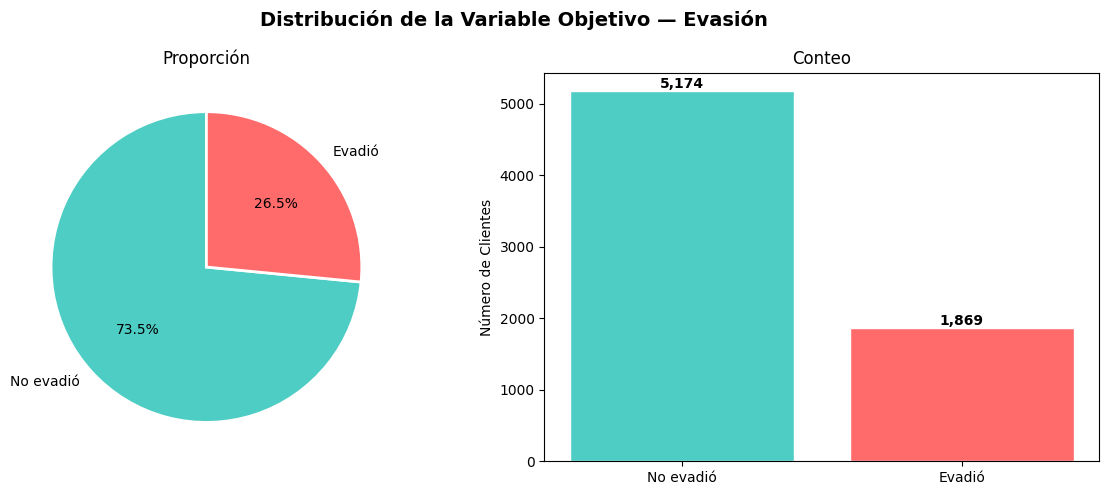

In [11]:
#Grafica
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribución de la Variable Objetivo — Evasión', fontsize=14, fontweight='bold')

colores = ['#4ECDC4', '#FF6B6B']

axes[0].pie(conteo.values, labels=['No evadió', 'Evadió'],
            autopct='%1.1f%%', colors=colores, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Proporción')

bars = axes[1].bar(['No evadió', 'Evadió'], conteo.values, color=colores, edgecolor='white')
axes[1].set_title('Conteo')
axes[1].set_ylabel('Número de Clientes')
for bar, val in zip(bars, conteo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.preprocessing import StandardScaler

#Separaración de features y target antes de escalar
X = df.drop(columns=['Evasion_Binaria'])
y = df['Evasion_Binaria']

#Escalar solo variables numéricas continuas
cols_escalar = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales']

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[cols_escalar] = scaler.fit_transform(X[cols_escalar])

print("\nEstadísticas tras estandarización:")
print(X_scaled[cols_escalar].describe().round(4))


Estadísticas tras estandarización:
       Meses_Contrato  Cargos_Mensuales  Cargos_Totales
count       7043.0000         7043.0000       7043.0000
mean          -0.0000           -0.0000         -0.0000
std            1.0001            1.0001          1.0001
min           -1.3182           -1.5459         -1.0058
25%           -0.9517           -0.9725         -0.8299
50%           -0.1373            0.1857         -0.3905
75%            0.9215            0.8338          0.6648
max            1.6137            1.7944          2.8258


# CORRELACION Y SELECCION DEVARIABLES

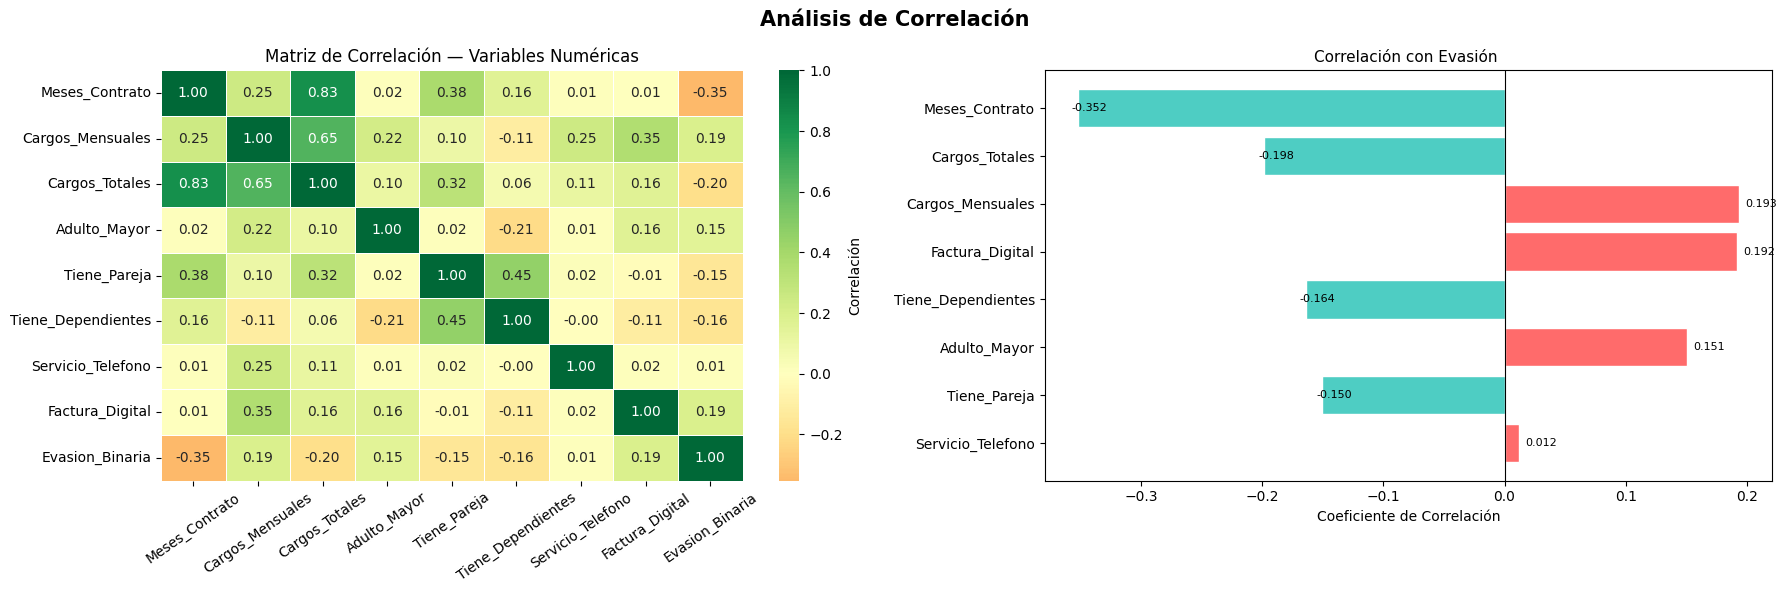

In [14]:
cols_corr = ['Meses_Contrato', 'Cargos_Mensuales', 'Cargos_Totales',
             'Adulto_Mayor', 'Tiene_Pareja', 'Tiene_Dependientes',
             'Servicio_Telefono', 'Factura_Digital', 'Evasion_Binaria']

cor_matrix = df[cols_corr].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Análisis de Correlación', fontsize=15, fontweight='bold')

# Heatmap completo
sns.heatmap(cor_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=axes[0],
            cbar_kws={'label': 'Correlación'})
axes[0].set_title('Matriz de Correlación — Variables Numéricas', fontsize=12)
axes[0].tick_params(axis='x', rotation=35)

# Ranking de correlación con Evasion_Binaria
corr_target = (cor_matrix['Evasion_Binaria']
               .drop('Evasion_Binaria')
               .sort_values(key=abs, ascending=True))
colors_bar = ['#FF6B6B' if v > 0 else '#4ECDC3' for v in corr_target.values]
axes[1].barh(corr_target.index, corr_target.values, color=colors_bar, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Correlación con Evasión ', fontsize=11)
axes[1].set_xlabel('Coeficiente de Correlación')
for i, (val, name) in enumerate(zip(corr_target.values, corr_target.index)):
    axes[1].text(val + (0.005 if val >= 0 else -0.005), i,
                 f'{val:.3f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()


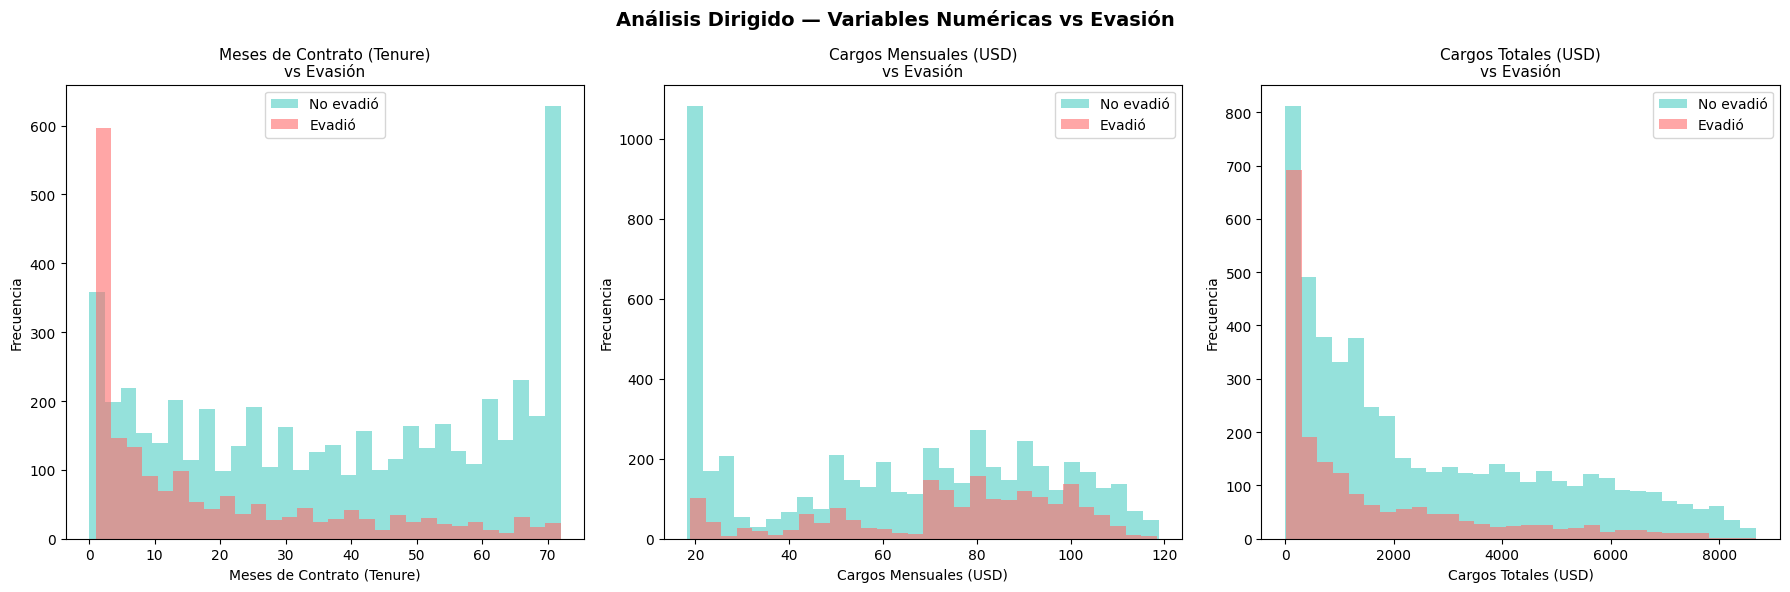

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Análisis Dirigido — Variables Numéricas vs Evasión', fontsize=14, fontweight='bold')

# Agregamos las llaves en formato texto para que Seaborn las encuentre
paleta = {0: '#4ECDC4', 1: '#FF6B6B', '0': '#4ECDC4', '1': '#FF6B6B'}
labels = {0: 'No evadió', 1: 'Evadió'}

pares = [
    ('Meses_Contrato',   'Meses de Contrato (Tenure)'),
    ('Cargos_Mensuales', 'Cargos Mensuales (USD)'),
    ('Cargos_Totales',   'Cargos Totales (USD)'),
]

for ax, (col, titulo) in zip(axes, pares):
    for val in [0, 1]:
        subset = df[df['Evasion_Binaria'] == val][col]
        ax.hist(subset, bins=30, alpha=0.6,
                color=paleta[val], label=labels[val], edgecolor='none')
    ax.set_title(f'{titulo}\nvs Evasión', fontsize=11)
    ax.set_xlabel(titulo)
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

# MODELADO PREDICTIVO


In [16]:
from sklearn.model_selection import train_test_split

#Separación con datos originales
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

#Separación con datos escalados (para Regresión Logística)
X_train_sc, X_test_sc, _, _ = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)


print(f"Entrenamiento: {X_train.shape[0]:,} registros ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Prueba:        {X_test.shape[0]:,} registros ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\nProporción de evasión en entrenamiento: {y_train.mean()*100:.1f}%")
print(f"Proporción de evasión en prueba:        {y_test.mean()*100:.1f}%")



Entrenamiento: 5,634 registros (80%)
Prueba:        1,409 registros (20%)

Proporción de evasión en entrenamiento: 26.5%
Proporción de evasión en prueba:        26.5%


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

#Modelo 1: Regresión Logística
modelo_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)
modelo_lr.fit(X_train_sc, y_train)

#Modelo 2: Random Forest
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
modelo_rf.fit(X_train, y_train)

print("Random_Forest y Logistica Terminada")
print(f"   Árboles: {modelo_rf.n_estimators}")
print(f"   Profundidad máxima: {modelo_rf.max_depth}")

Random_Forest y Logistica Terminada
   Árboles: 200
   Profundidad máxima: 12



📊 MODELO: Regresión Logística
               precision    recall  f1-score   support

No evadió (0)       0.90      0.72      0.80      1035
   Evadió (1)       0.51      0.78      0.61       374

     accuracy                           0.74      1409
    macro avg       0.70      0.75      0.71      1409
 weighted avg       0.80      0.74      0.75      1409


📊 MODELO: Random Forest
               precision    recall  f1-score   support

No evadió (0)       0.87      0.83      0.85      1035
   Evadió (1)       0.58      0.67      0.62       374

     accuracy                           0.78      1409
    macro avg       0.73      0.75      0.74      1409
 weighted avg       0.80      0.78      0.79      1409



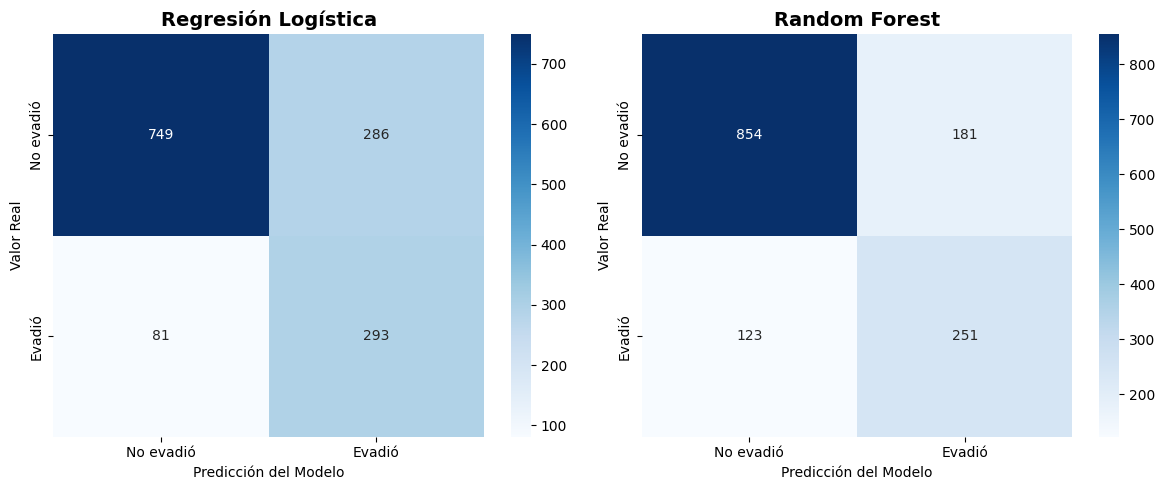


📊 COMPARATIVA FINAL


,Modelo,Accuracy,Precisión,Recall,F1-Score
0,Regresión Logística,0.739532,0.506045,0.783422,0.614900
1,Random Forest,0.784244,0.581019,0.671123,0.622829


In [22]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score)

#Funcion que evalua los modelos
def evaluar_y_reportar(nombre, modelo, X, y):
    y_pred = modelo.predict(X)

    # Imprimimos el reporte detallado en texto
    print(f"\n{'='*40}\n📊 MODELO: {nombre}\n{'='*40}")
    print(classification_report(y, y_pred, target_names=['No evadió (0)', 'Evadió (1)']))

    # Guardamos las métricas en un diccionario para facilitar la tabla final
    metricas = {
        'Modelo': nombre,
        'Accuracy': accuracy_score(y, y_pred),
        'Precisión': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1-Score': f1_score(y, y_pred)
    }
    return metricas, y_pred

# 2. Evaluamos ambos modelos
# (Ojo: respetamos que tu Regresión Logística usa X_test_sc escalado)
res_lr, pred_lr = evaluar_y_reportar("Regresión Logística", modelo_lr, X_test_sc, y_test)
res_rf, pred_rf = evaluar_y_reportar("Random Forest", modelo_rf, X_test, y_test)

# 3. Dibujamos las matrices de confusión de forma más limpia
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
predicciones = [("Regresión Logística", pred_lr), ("Random Forest", pred_rf)]

for ax, (nombre, pred) in zip(axes, predicciones):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No evadió', 'Evadió'],
                yticklabels=['No evadió', 'Evadió'])
    ax.set_title(nombre, fontsize=14, fontweight='bold')
    ax.set_xlabel('Predicción del Modelo')
    ax.set_ylabel('Valor Real')

plt.tight_layout()
plt.show()

# 4. Tabla comparativa final (Pandas la arma sola usando los diccionarios)
print("\n" + "=" * 40 + "\n📊 COMPARATIVA FINAL\n" + "=" * 40)
comparativa = pd.DataFrame([res_lr, res_rf])
display(comparativa)

# INTERPRETACION Y CONCLUSIONES

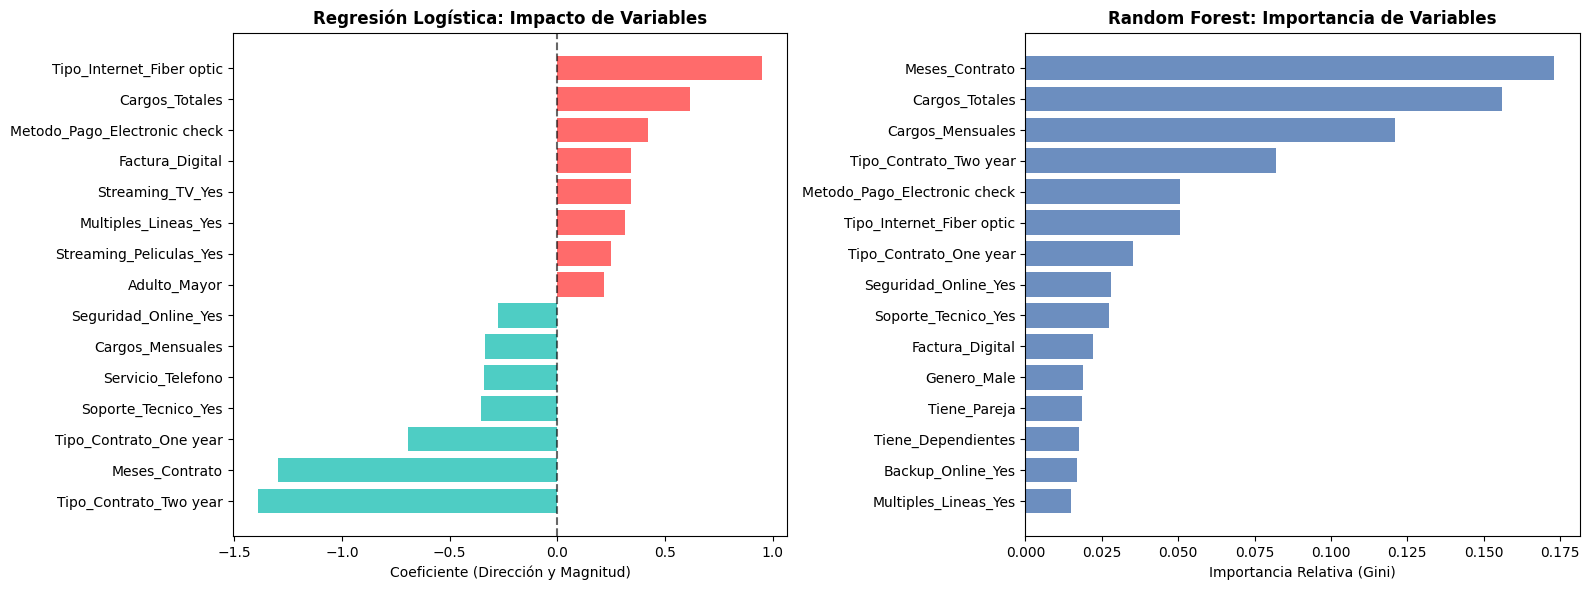


📊 TOP 10 VARIABLES MÁS IMPORTANTES (RF)
Meses_Contrato                  0.1729
Cargos_Totales                  0.1559
Cargos_Mensuales                0.1209
Tipo_Contrato_Two year          0.0821
Metodo_Pago_Electronic check    0.0507
Tipo_Internet_Fiber optic       0.0504
Tipo_Contrato_One year          0.0354
Seguridad_Online_Yes            0.0281
Soporte_Tecnico_Yes             0.0275
Factura_Digital                 0.0222


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Regresión Logística (Top 15 Coeficientes)
# Extraemos coeficientes, tomamos los 15 con mayor valor absoluto y los ordenamos
coef_lr = pd.Series(modelo_lr.coef_[0], index=X.columns)
top15_lr = coef_lr.reindex(coef_lr.abs().sort_values(ascending=False).index[:15]).sort_values()

# Colores: Rojo si aumenta la evasión (>0), Verde si ayuda a retener (<0)
colores_lr = ['#FF6B6B' if val > 0 else '#4ECDC4' for val in top15_lr]

axes[0].barh(top15_lr.index, top15_lr, color=colores_lr)
axes[0].axvline(0, color='black', linestyle='--', alpha=0.6)
axes[0].set_title('Regresión Logística: Impacto de Variables', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Coeficiente (Dirección y Magnitud)')

# 2. Random Forest (Top 15 Importancia Relativa)
# Extraemos las 15 variables con mayor peso en las decisiones del árbol
imp_rf = pd.Series(modelo_rf.feature_importances_, index=X.columns)
top15_rf = imp_rf.sort_values(ascending=False)[:15].sort_values()

axes[1].barh(top15_rf.index, top15_rf, color='#6C8EBF')
axes[1].set_title('Random Forest: Importancia de Variables', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importancia Relativa (Gini)')

plt.tight_layout()
plt.show()

# 3. Resumen en texto con el mismo estilo del bloque anterior
print("\n" + "=" * 40 + "\n📊 TOP 10 VARIABLES MÁS IMPORTANTES (RF)\n" + "=" * 40)
print(imp_rf.sort_values(ascending=False)[:10].round(4).to_string())

## REPORTE FINAL
Este analisis sale por el deseo de desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios.
La empresa quiere anticiparse al problema de la cancelación, y te corresponde a ti construir un pipeline robusto para esta etapa inicial de modelado.

## Tratamiento de Datos y Desbalanceo
El dataset presenta un desbalanceo de clases moderado (ratio ~3:1), compuesto por un 73.5% de retención frente a un 26.5% de evasión. Para mitigar el sesgo algorítmico hacia la clase mayoritaria sin alterar la distribución original mediante técnicas de resampling, se aplicó el hiperparámetro class_weight='balanced' durante el entrenamiento, garantizando una penalización proporcional de los errores sobre la clase minoritaria.

## Análisis de Correlaciones
La exploración bivariada identificó las siguientes dinámicas críticas sobre la probabilidad de abandono:
* Permanencia (Meses_Contrato): Correlación negativa fuerte. La vulnerabilidad es máxima en las etapas tempranas del ciclo de vida del cliente.
* Costos (Cargos_Mensuales): Correlación positiva. La sensibilidad al precio eleva sustancialmente el riesgo de cancelación.
* Fidelización (Tipo_Contrato): Correlación negativa respecto a esquemas a largo plazo. Los contratos anuales y bianuales actúan como escudos protectores.

##Evaluación del Rendimiento
Aunque el modelo de Random Forest acierta un poco más a nivel general (~82%), la Regresión Logística resultó ser la herramienta más útil para el objetivo del negocio. Esto se debe a que tiene una mayor capacidad (~74%) para identificar específicamente a los clientes que están a punto de cancelar su servicio.

Para la empresa, es mucho más rentable y seguro invertir esfuerzos en contactar por error a un cliente leal para ofrecerle una promoción, que perder ingresos reales por no detectar a tiempo a un cliente que sí se iba a ir. Además, las pruebas confirmaron que ambos modelos son muy estables y confiables para usarse con datos nuevos en el mundo real.

## Predictores Fundamentales
La impureza de Gini (Random Forest) y la magnitud de los coeficientes (Regresión Logística) convergen en la identificación de las siguientes variables determinantes:
* Antigüedad (Tenure): Es el predictor dominante. Los primeros meses de servicio constituyen la zona crítica de atrición.
* Volumen de Facturación: Las cuotas mensuales elevadas incrementan la fricción percibida.
* Contratos "Mes a Mes": Representan la principal falla estructural en la retención.
* Método de Pago: El uso de cheque electrónico denota un perfil transaccional de alto riesgo frente a la domiciliación bancaria.

##Recomendaciones Estratégicas
Para la puesta en producción del pipeline analítico, se propone:
* Sistema de alerta temprana: Implementar el modelo Random Forest en el entorno de producción para generar un scoring de riesgo mensual, identificando a los clientes con mayor probabilidad de evasión y priorizando analíticamente a aquellos con una permanencia inferior a 12 meses.
*Auditoría de la propuesta de valor premium: Reevaluar la relación costo-beneficio de los planes más costosos, dado que la atrición en este segmento señala una disonancia entre el precio de mercado y el valor percibido por el usuario.
* Protocolos de fidelización temprana: Desarrollar un programa intensivo de onboarding y seguimiento proactivo durante los primeros 6 meses de servicio, identificado estadísticamente como el período crítico de máxima vulnerabilidad.

